In [1]:
from google.colab import drive
drive.mount('/content/drive')
!unzip -q /content/drive/MyDrive/realwaste.zip -d /content/realwaste/

Mounted at /content/drive


In [2]:
!pip install scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 12.0 MB/s eta 0:00:00


In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import time
import os
import glob
import pandas as pd
import skfuzzy as fuzz
from sklearn.metrics import silhouette_score
from tqdm.notebook import tqdm


def interpretasi_sampah(centroids):
    skor = [
        (10 if 0.05 <= h <= 0.48 else 0) +
        (2 if 0.2 <= s <= 0.7 else 0)
        for h, s, _ in centroids
    ]

    if skor[0] != skor[1]:
        idx_organik = int(np.argmax(skor))
    else:
        idx_organik = int(np.argmin(centroids[:, 1]))

    return idx_organik, 1 - idx_organik


FOLDER_ORGANIK = {'food organics', 'vegetation'}


def ambil_label_asli(path_gambar):
    nama_folder = os.path.basename(os.path.dirname(path_gambar)).lower()
    return 'Organik' if nama_folder in FOLDER_ORGANIK else 'Anorganik'


def proses_satu_gambar_fcm(path_gambar):
    img_bgr = cv2.imread(path_gambar)

    if img_bgr is None:
        return None

    img_resized = cv2.resize(img_bgr, (150, 150))

    img_hsv = cv2.cvtColor(
        cv2.GaussianBlur(img_resized, (5, 5), 0),
        cv2.COLOR_BGR2HSV
    )

    h, w, _ = img_hsv.shape

    piksel = img_hsv.reshape(-1, 3).astype(np.float32)
    piksel /= np.array([179.0, 255.0, 255.0])

    data_fcm = piksel.T

    mulai = time.perf_counter()

    cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
        data_fcm,
        c=2,
        m=2.0,
        error=1e-4,
        maxiter=30,
        init=None,
        seed=42
    )

    waktu = time.perf_counter() - mulai

    labels = np.argmax(u, axis=0)

    silhouette = silhouette_score(
        piksel,
        labels,
        sample_size=2000,
        random_state=42
    )

    idx_org, idx_anorg = interpretasi_sampah(cntr)

    warna = {'organik': [0, 255, 0], 'anorganik': [0, 0, 255]}
    seg = np.zeros((len(labels), 3), dtype=np.uint8)
    seg[labels == idx_org] = warna['organik']
    seg[labels == idx_anorg] = warna['anorganik']
    hasil_seg = seg.reshape(h, w, 3)

    proporsi_organik = np.sum(labels == idx_org) / len(labels)
    prediksi = 'Organik' if proporsi_organik >= 0.5 else 'Anorganik'

    return {
        'img_resized': img_resized,
        'hasil_seg': hasil_seg,
        'prediksi': prediksi,
        'waktu': waktu,
        'silhouette': silhouette
    }


Total gambar ditemukan: 4752


FCM Batch:   0%|          | 0/4752 [00:00<?, ?it/s]

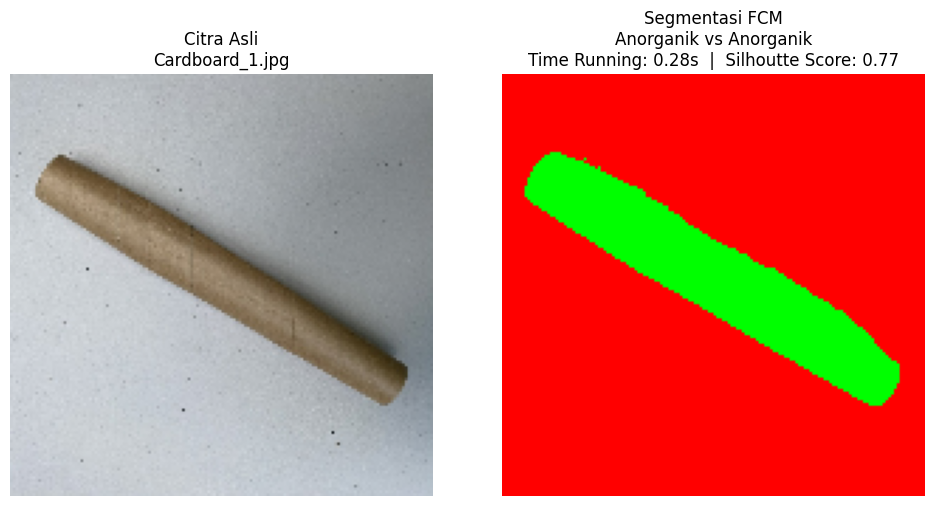

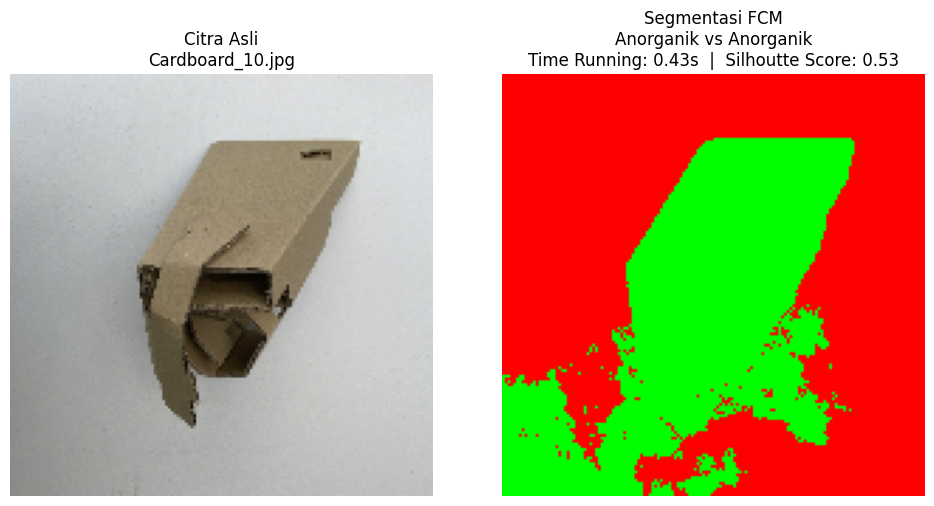

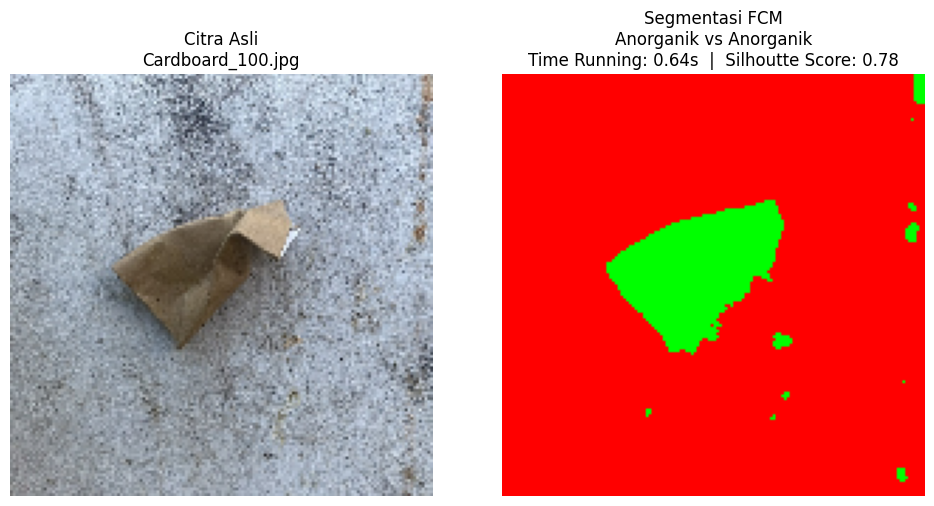

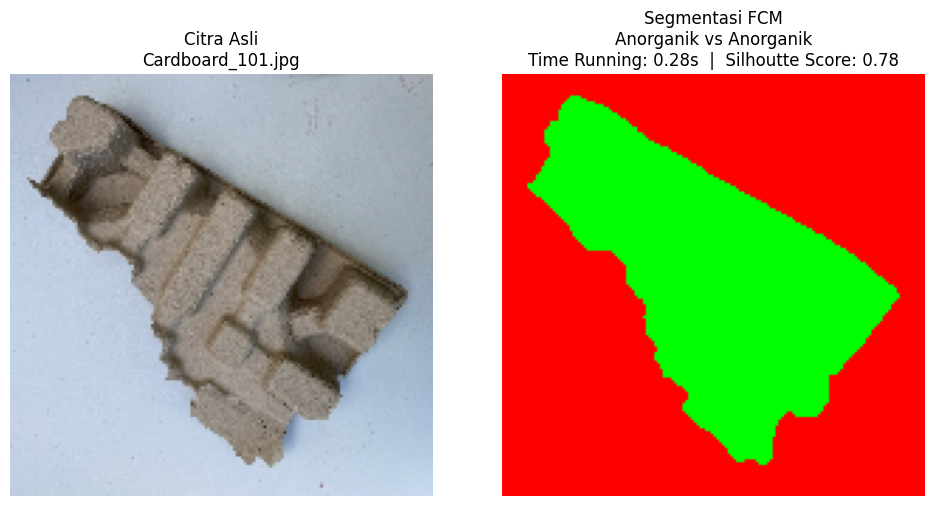

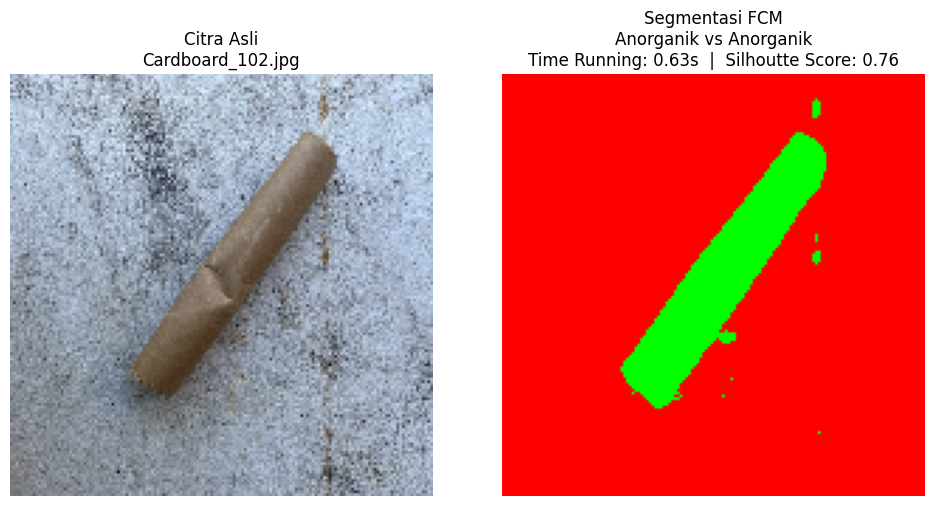


Ekspor selesai: /content/drive/MyDrive/rekapan_evaluasi_FCM.csv
Total baris terekap: 4752

Ringkasan Akurasi:
Algoritma
FCM    43.22
Name: Akurasi (%), dtype: float64


,Nama File,Label Asli,Hasil Prediksi Model,Algoritma,Metrik Jarak,Waktu Eksekusi (s),Silhouette Score,Akurasi (%)
0,Cardboard_1.jpg,Anorganik,Anorganik,FCM,Euclidean (default FCM),0.2782,0.7655,100
1,Cardboard_10.jpg,Anorganik,Anorganik,FCM,Euclidean (default FCM),0.4334,0.5314,100
2,Cardboard_100.jpg,Anorganik,Anorganik,FCM,Euclidean (default FCM),0.6405,0.7768,100
3,Cardboard_101.jpg,Anorganik,Anorganik,FCM,Euclidean (default FCM),0.2794,0.7781,100
4,Cardboard_102.jpg,Anorganik,Anorganik,FCM,Euclidean (default FCM),0.6290,0.7636,100
5,Cardboard_103.jpg,Anorganik,Anorganik,FCM,Euclidean (default FCM),0.7768,0.4216,100
6,Cardboard_104.jpg,Anorganik,Anorganik,FCM,Euclidean (default FCM),0.3620,0.4768,100
7,Cardboard_105.jpg,Anorganik,Anorganik,FCM,Euclidean (default FCM),0.2955,0.5125,100
8,Cardboard_106.jpg,Anorganik,Anorganik,FCM,Euclidean (default FCM),0.2407,0.7023,100
9,Cardboard_107.jpg,Anorganik,Anorganik,FCM,Euclidean (default FCM),0.2371,0.7419,100


In [5]:
FOLDER_DATASET = '/content/realwaste/'
BATAS_VISUALISASI = 5

semua_gambar = sorted(
    glob.glob(os.path.join(FOLDER_DATASET, '**', '*.jpg'), recursive=True)
)

print(f"Total gambar ditemukan: {len(semua_gambar)}")

rekap_data = []

for nomor_gambar, path in enumerate(tqdm(semua_gambar, desc='FCM Batch')):
    nama_file = os.path.basename(path)
    label_asli = ambil_label_asli(path)

    hasil = proses_satu_gambar_fcm(path)

    if hasil is None:
        continue

    akurasi = 100 if hasil['prediksi'] == label_asli else 0

    rekap_data.append({
        'Nama File': nama_file,
        'Label Asli': label_asli,
        'Hasil Prediksi Model': hasil['prediksi'],
        'Algoritma': 'FCM',
        'Metrik Jarak': 'Euclidean (default FCM)',
        'Waktu Eksekusi (s)': round(hasil['waktu'], 4),
        'Silhouette Score': round(hasil['silhouette'], 4),
        'Akurasi (%)': akurasi
    })

    if nomor_gambar < BATAS_VISUALISASI:
        fig, axes = plt.subplots(1, 2, figsize=(10, 5))

        axes[0].imshow(cv2.cvtColor(hasil['img_resized'], cv2.COLOR_BGR2RGB))
        axes[0].set_title(f"Citra Asli\n{nama_file}")
        axes[0].axis('off')

        axes[1].imshow(cv2.cvtColor(hasil['hasil_seg'], cv2.COLOR_BGR2RGB))
        axes[1].set_title(
            f"Segmentasi FCM\n"
            f"{label_asli} vs {hasil['prediksi']}\n"
            f"Time Running: {hasil['waktu']:.2f}s  |  Silhoutte Score: {hasil['silhouette']:.2f}"
        )
        axes[1].axis('off')

        plt.tight_layout()
        plt.show()
        plt.close()


df_rekap = pd.DataFrame(rekap_data)

path_output = '/content/drive/MyDrive/rekapan_evaluasi_FCM.csv'
df_rekap.to_csv(path_output, index=False)

print(f"\nEkspor selesai: {path_output}")
print(f"Total baris terekap: {len(df_rekap)}")
print(f"\nRingkasan Akurasi:")
print(df_rekap.groupby('Algoritma')['Akurasi (%)'].mean().round(2))
df_rekap.head(10)